# Step 5 — Semantic ID Tokenizer (RQ-VAE)

Both baselines (Step 4) only know an item or user exists if it showed up in training. This
step fixes that for items: instead of an arbitrary integer ID, every item gets a **Semantic
ID** -- a short tuple of codes derived from its content, produced by an RQ-VAE
(residual-quantized autoencoder). Similar items land on similar codes, and a brand-new item
gets a valid, meaningful ID the moment it enters the catalog, with zero interactions.

This is the mechanism TIGER (Google DeepMind, NeurIPS 2023,
[arXiv](https://arxiv.org/abs/2305.05065)) uses to make items *generatable* -- which is what
Step 6's Transformer needs.

Full writeup: `docs/05_semantic_ids.md` -- includes the full story behind two framework
detours (JAX for the RQ-VAE since PyTorch doesn't fit the sandbox; Sentence-T5 embeddings
generated on Colab GPU since transformers v5 dropped Flax support) and a real training
failure (total codebook collapse from unstandardized anisotropic embeddings) this notebook
reproduces and fixes below, not just glosses over.

In [1]:
import os
import sys
import json
from collections import Counter

sys.path.insert(0, os.path.abspath(os.path.join("..", "backend")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

import jax
import jax.numpy as jnp

from models import rqvae

PROCESSED_DIR = os.path.join("..", "data", "processed")
pd.set_option("display.max_colwidth", 80)

## Item content embeddings

Generated on Colab GPU via `sentence-transformers/sentence-t5-base` (~110M-param encoder,
768-dim output) -- see `backend/scripts/build_item_embeddings_local.py` and
`notebooks/colab_item_embeddings.ipynb`. Loading the precomputed result here rather than
recomputing: this specific model needs PyTorch, which doesn't fit in this sandbox (see
`docs/05_semantic_ids.md` for the full framework-detour story).

In [2]:
item_catalog = pd.read_parquet(os.path.join(PROCESSED_DIR, "item_catalog.parquet")).sort_values("item_id").reset_index(drop=True)
titles = item_catalog["description"].fillna("").tolist()

embeddings = np.load(os.path.join(PROCESSED_DIR, "item_embeddings.npy"))
print(f"{len(titles):,} items, embeddings: {embeddings.shape}")

25,612 items, embeddings: (25612, 768)


In [3]:
# sanity check before trusting this as RQ-VAE input: do nearest neighbors look related?
sample_idx = titles.index("Gunstar Heroes - Sega Genesis") if "Gunstar Heroes - Sega Genesis" in titles else 0
sims = cosine_similarity(embeddings[sample_idx:sample_idx+1], embeddings)[0]
top = np.argsort(-sims)[1:6]
print(f"'{titles[sample_idx]}' nearest neighbors:")
for j in top:
    print(f"  {sims[j]:.3f}  {titles[j]}")

'Gunstar Heroes - Sega Genesis' nearest neighbors:
  0.935  Starflight - Sega Genesis
  0.930  Gunstar Super Heroes
  0.926  Gaiares - Sega Genesis
  0.925  Phantasy Star II - Sega Genesis
  0.918  Phantasy Star IV - Sega Genesis


## Anisotropy: a hidden landmine

The first attempt to train the RQ-VAE on these embeddings failed silently -- loss looked
fine, but every single item collapsed onto the exact same code. The cause: BERT-family
sentence embeddings are anisotropic -- almost all of a vector's magnitude sits in one shared
direction, so unrelated items look deceptively "similar" to a small encoder. Measuring this
directly, rather than guessing:

In [4]:
rng = np.random.RandomState(0)
sample = embeddings[rng.choice(len(embeddings), 2000, replace=False)]
sims_matrix = sample @ sample.T
mask = ~np.eye(len(sample), dtype=bool)
print(f"avg pairwise cosine similarity, RAW embeddings: {sims_matrix[mask].mean():.4f}")
print("(should be near 0 for unrelated random items -- 0.76 means they all look almost identical)")

avg pairwise cosine similarity, RAW embeddings: 0.7634
(should be near 0 for unrelated random items -- 0.76 means they all look almost identical)


**Fix:** standardize (center + scale to unit variance per dimension) before the encoder
ever sees the data. This directly attacks the shared dominant direction.

In [5]:
emb_mean = embeddings.mean(axis=0, keepdims=True)
emb_std = embeddings.std(axis=0, keepdims=True)
embeddings_std = ((embeddings - emb_mean) / (emb_std + 1e-8)).astype("float32")

sample_std = embeddings_std[rng.choice(len(embeddings_std), 2000, replace=False)]
sample_std_n = sample_std / np.linalg.norm(sample_std, axis=1, keepdims=True)
sims_matrix2 = sample_std_n @ sample_std_n.T
print(f"avg pairwise cosine similarity, STANDARDIZED embeddings: {sims_matrix2[mask].mean():.4f}")

avg pairwise cosine similarity, STANDARDIZED embeddings: 0.0002


## The RQ-VAE

`backend/models/rqvae.py`. An encoder compresses the 768-dim (standardized) embedding down to
a 32-dim latent vector; a decoder reconstructs it. In between, **residual quantization**
snaps the latent vector to a discrete code using 3 small codebooks in sequence -- codebook 1
quantizes the vector, codebook 2 quantizes what codebook 1 got wrong (the residual), codebook
3 cleans up what's still left. 3 codebooks of 256 codes give ~16.7M possible combinations
from only 768 learned vectors total.

Codebook initialization matters more than it might look: small-random-noise init (fine for
the earlier TF-IDF embeddings) is what caused the collapse above. Here, each codebook is
seeded via a few rounds of k-means directly on the freshly-initialized encoder's own outputs
(`rqvae.kmeans_init_codebooks`) -- so the codebook starts in the actual region of space the
encoder produces, instead of hoping training finds it.

In [6]:
HIDDEN_DIM, LATENT_DIM, N_CODEBOOKS, CODEBOOK_SIZE = 256, 32, 3, 256

key = jax.random.PRNGKey(42)
init_key, codebook_key = jax.random.split(key)
in_dim = embeddings_std.shape[1]
params = rqvae.init_params(init_key, in_dim, HIDDEN_DIM, LATENT_DIM, N_CODEBOOKS, CODEBOOK_SIZE)

z0 = rqvae.encode(params, jnp.array(embeddings_std))
params["codebooks"] = rqvae.kmeans_init_codebooks(codebook_key, z0, N_CODEBOOKS, CODEBOOK_SIZE)

n_params = sum(int(np.prod(p.shape)) for p in jax.tree_util.tree_leaves(params))
print(f"encoder/decoder + {N_CODEBOOKS} codebooks of {CODEBOOK_SIZE} codes each: {n_params:,} total parameters")

encoder/decoder + 3 codebooks of 256 codes each: 435,488 total parameters


## Training

Batch size 1024, Adam (lr 2e-3), full 25,612-item catalog, on the standardized embeddings
with k-means-initialized codebooks. Loss is reconstruction error + a codebook loss + 0.25x a
commitment loss, using a straight-through estimator so gradients can flow through the
(otherwise non-differentiable) quantization step.

This notebook runs 150 epochs for interactive speed (real embeddings are heavier to train on
than the old TF-IDF ones -- ~0.6s/epoch here vs ~0.25s/epoch before). Production
`semantic_ids.parquet` used the full 400 epochs, documented in `docs/05_semantic_ids.md`;
same seed, so this is a strict prefix of that run.

In [7]:
EPOCHS, BATCH_SIZE, LR, BETA, SEED = 150, 1024, 2e-3, 0.25, 42

x = jnp.array(embeddings_std)
n_items = x.shape[0]
opt_init, opt_update = rqvae.make_adam(lr=LR)
opt_state = opt_init(params)
loss_and_grad = jax.jit(jax.value_and_grad(lambda p, batch: rqvae.forward(p, batch, beta=BETA)[0]))

n_batches = max(1, n_items // BATCH_SIZE)
history = []
rng2 = np.random.RandomState(SEED)

for epoch in range(EPOCHS):
    perm = rng2.permutation(n_items)
    epoch_loss = 0.0
    for b in range(n_batches):
        idx = perm[b * BATCH_SIZE : (b + 1) * BATCH_SIZE]
        loss, grads = loss_and_grad(params, x[idx])
        params, opt_state = opt_update(grads, opt_state, params)
        epoch_loss += float(loss)
    epoch_loss /= n_batches
    history.append(epoch_loss)
    if epoch % 30 == 0 or epoch == EPOCHS - 1:
        print(f"epoch {epoch:4d}  loss {epoch_loss:.5f}")

epoch    0  loss 3.35989
epoch   30  loss 1.09814
epoch   60  loss 1.09304
epoch   90  loss 1.08355
epoch  120  loss 1.06680
epoch  149  loss 1.04890


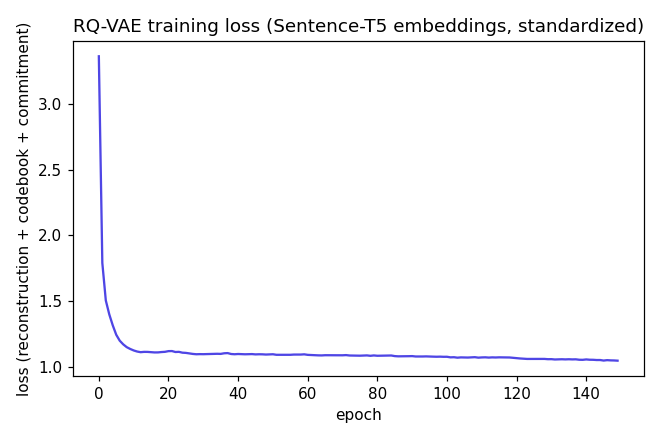

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history, color="#4F46E5")
ax.set_title("RQ-VAE training loss (Sentence-T5 embeddings, standardized)")
ax.set_xlabel("epoch")
ax.set_ylabel("loss (reconstruction + codebook + commitment)")
plt.tight_layout()
plt.show()

## Assigning Semantic IDs

Encode + quantize every item to get its raw 3-level code, then check codebook health (usage
per level -- how many of the 256 possible codes actually got assigned to at least one item)
and how many items collide on the same 3-digit tuple.

In [9]:
codes = np.array(rqvae.get_codes(params, x))  # (n_items, N_CODEBOOKS)

tuples = [tuple(row) for row in codes]
counts = Counter(tuples)
n_colliding_items = sum(c for c in counts.values() if c > 1)
print(f"{len(counts):,} unique {N_CODEBOOKS}-level code tuples for {n_items:,} items")
print(f"{n_colliding_items:,} items ({100*n_colliding_items/n_items:.1f}%) share a tuple with at least one other item")

print()
for l in range(N_CODEBOOKS):
    used = len(set(codes[:, l].tolist()))
    print(f"level {l+1}: {used}/{CODEBOOK_SIZE} codes used ({100*used/CODEBOOK_SIZE:.0f}%)")

20,965 unique 3-level code tuples for 25,612 items
7,532 items (29.4%) share a tuple with at least one other item

level 1: 58/256 codes used (23%)
level 2: 243/256 codes used (95%)
level 3: 245/256 codes used (96%)


In [10]:
# TIGER's fix for collisions: append a 4th "dedup" digit, a running counter per colliding tuple
seen = {}
dedup_digit = np.zeros(n_items, dtype=np.int32)
for i, t in enumerate(tuples):
    dedup_digit[i] = seen.get(t, 0)
    seen[t] = seen.get(t, 0) + 1

semantic_ids = np.concatenate([codes, dedup_digit[:, None]], axis=1)
assert len(set(map(tuple, semantic_ids))) == n_items
print(f"after adding the dedup digit: all {n_items:,} Semantic IDs are unique")

item_catalog["semantic_id"] = [tuple(row) for row in semantic_ids]
item_catalog[["item_id", "description", "semantic_id"]].head()

after adding the dedup digit: all 25,612 Semantic IDs are unique


,item_id,description,semantic_id
0,0,Wonder,"(117, 105, 196, 0)"
1,1,"The Other Wes Moore: One Name, Two Fates","(35, 123, 46, 0)"
2,2,Born a Crime: Stories from a South African Childhood,"(35, 187, 25, 0)"
3,3,Activision Skylanders Giants Single Character Pack - Molten Hot Dog,"(245, 51, 79, 0)"
4,4,HITMAN ABSOLUTION (PC),"(120, 178, 19, 0)"


## Does it actually mean something?

The real test: pick items that share a code and see whether they're actually related, given
the model was never told what "related" means -- only trained to reconstruct.

In [11]:
level1 = codes[:, 0]
sample_code = pd.Series(level1).value_counts().index[0]
members = np.where(level1 == sample_code)[0][:5]
print(f"5 items sharing level-1 code {sample_code}:")
for i in members:
    print(f"  {tuple(codes[i])}  {item_catalog.loc[i, 'description']}")

5 items sharing level-1 code 62:
  (np.int32(62), np.int32(188), np.int32(241))  Logitech Extreme PC Gaming Headset
  (np.int32(62), np.int32(188), np.int32(241))  Logitech Precision PC Gaming Headset
  (np.int32(62), np.int32(188), np.int32(72))  GameComPro1 PC Gaming Headset
  (np.int32(62), np.int32(48), np.int32(221))  D & H Distributing Co PC Headset with Microphone
  (np.int32(62), np.int32(91), np.int32(224))  Saitek Eclipse Keyboard (PZ30AU)


In [12]:
# a concrete collision: two different items landing on the exact same 3-digit tuple
dupe_tuple = next(t for t, c in counts.items() if c == 2)
rows = item_catalog[item_catalog["semantic_id"].apply(lambda t: t[:3] == dupe_tuple)]
print(f"items colliding on {dupe_tuple} (disambiguated by the 4th dedup digit):")
print(rows[["item_id", "description", "semantic_id"]].to_string(index=False))

items colliding on (np.int32(235), np.int32(74), np.int32(221)) (disambiguated by the 4th dedup digit):
 item_id                              description       semantic_id
      15 Adventure Time: Card Wars: Finn vs. Jake (235, 74, 221, 0)
   11320 Adventure Time: Card Wars: Finn vs. Jake (235, 74, 221, 1)


## What's next

`semantic_ids.parquet` plus `train_sequences.parquet` feed Step 6: a decoder-only
Transformer that reads a user's history as a sequence of Semantic IDs and learns to
generate the next one -- retrieval as generation instead of nearest-neighbor search, the
architectural bet both TIGER and Meta's HSTU make.